---

# ⚛️ Múltiples qubits en Qiskit

### Estados compuestos, superposición y entrelazamiento

**INTRODUCCIÓN A LA PROGRAMACIÓN CUÁNTICA · CENIDET**  
**TECNOLÓGICO NACIONAL DE MÉXICO**

`NIVEL INICIAL` · `QISKIT` · `GOOGLE COLAB`

---

**Oscar Alejandro López Campero**  
Maestría en Ciencias de la Computación · Línea de Ingeniería de Software  
Agosto 2026

---

## 🧭 Ruta de aprendizaje

> **Objetivo del módulo:** construir y visualizar sistemas de dos qubits, interpretar el orden de sus estados base y generar superposición y entrelazamiento con circuitos sencillos.

| | Sección | ¿Qué aprenderás? |
|:--:|---|---|
| **01** | 🧩 Sistemas de dos qubits | Interpretar la base computacional |
| **02** | 🔄 Operaciones individuales | Aplicar X a uno o ambos qubits |
| **03** | ✳️ Superposición | Aplicar H en sistemas compuestos |
| **04** | 🔗 Entrelazamiento | Construir un estado de Bell |
| **05** | 🔀 Orden de compuertas | Comparar H → X y X → H |
| **06** | 🔔 Estados de Bell | Construir Φ⁺, Φ⁻, Ψ⁺ y Ψ⁻ |
| **07** | 🧪 Ejercicios | Resolver retos sin respuestas visibles |

### En cada ejemplo observaremos

| Representación | Información que aporta |
|---|---|
| Circuito | Operaciones, qubits y orden temporal |
| Vector | Amplitud de cada estado base |
| Notación ket | Estado compuesto en forma simbólica |
| QSphere | Probabilidades y fases del sistema completo |

---

# 🟩 PREPARACIÓN

# 🛠️ Configuración del entorno

Ejecuta estas celdas al comenzar. En Google Colab la instalación debe repetirse cuando se inicia una sesión nueva.

> 💡 Ejecuta una celda con el botón ▶ o con `Shift + Enter`.

In [1]:
# El símbolo % permite ejecutar pip dentro del entorno del notebook.
# Qiskit contiene las clases para crear y analizar circuitos cuánticos.
# El extra "visualization" instala las herramientas para generar figuras.
%pip install -q "qiskit[visualization]"

print("✅ Qiskit está instalado")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ Qiskit está instalado


In [2]:
# IMPORTAR significa traer herramientas de las bibliotecas instaladas.
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex, plot_state_qsphere
from IPython.display import display

print("✅ Herramientas importadas")

✅ Herramientas importadas


## Antes de programar: símbolos básicos de Python

| Elemento | Significado | Ejemplo |
|---|---|---|
| `# comentario` | Explica una línea; Python no la ejecuta | `# Crear circuito` |
| `=` | Guarda un objeto bajo un nombre | `circuito = QuantumCircuit(2)` |
| `objeto.metodo()` | Pide al objeto realizar una acción | `circuito.x(0)` |
| `0` | Índice del primer qubit | `x(0)` actúa sobre `q₀` |
| `1` | Índice del segundo qubit | `x(1)` actúa sobre `q₁` |

> ⚠️ En programación contamos desde cero: el primer qubit es `q₀` y el segundo es `q₁`.

---

# 🟪 SECCIÓN 01

# 🧩 Sistemas de dos qubits

Un qubit posee dos estados base. Al combinar dos qubits obtenemos cuatro estados:

| Etiqueta | Estado de `q₁` | Estado de `q₀` |
|:--:|:--:|:--:|
| ∣00⟩ | 0 | 0 |
| ∣01⟩ | 0 | 1 |
| ∣10⟩ | 1 | 0 |
| ∣11⟩ | 1 | 1 |

Cualquier estado de dos qubits puede escribirse como:

$$
|\psi\rangle=\alpha|00\rangle+\beta|01\rangle+\gamma|10\rangle+\delta|11\rangle
$$

con $|\alpha|^2+|\beta|^2+|\gamma|^2+|\delta|^2=1$.

## Orden de qubits en Qiskit

Qiskit utiliza la etiqueta $q_1q_0$ para mostrar un estado de dos qubits:

```text
ket mostrado:       | q₁ q₀ ⟩
circuito dibujado:  q₀ aparece arriba
                    q₁ aparece abajo
```

Por ello:

| Operación desde ∣00⟩ | Estado resultante |
|---|:--:|
| `x(0)` | ∣01⟩ |
| `x(1)` | ∣10⟩ |
| `x(0)` y `x(1)` | ∣11⟩ |

> 🧠 **Regla útil:** `q₀` aparece a la derecha del ket, aunque se dibuje como la primera línea del circuito.

## 🧿 Introducción a la QSphere

La **QSphere** es una visualización de Qiskit para representar el **estado completo de uno o varios qubits**. Cada estado de la base computacional ocupa un punto sobre la esfera.

> 💡 No es una esfera física: es un mapa de amplitudes, probabilidades y fases.

### ¿Qué significa cada elemento?

| Elemento | Interpretación |
|---|---|
| Etiqueta | Estado base, como ∣00⟩ o ∣11⟩ |
| Tamaño del punto | Probabilidad de obtener ese estado |
| Color del punto | Fase de la amplitud |
| Polo norte | Estado con todos los qubits en `0` |
| Polo sur | Estado con todos los qubits en `1` |
| Latitudes | Estados agrupados por su cantidad de unos |

### Posiciones para dos qubits

| Posición | Estados | Cantidad de unos |
|:--:|:--:|:--:|
| Polo norte | ∣00⟩ | 0 |
| Zona intermedia | ∣01⟩ y ∣10⟩ | 1 |
| Polo sur | ∣11⟩ | 2 |

### Cómo leer una QSphere

1. **Lee las etiquetas** para identificar los estados presentes.
2. **Compara los tamaños:** un punto mayor representa más probabilidad.
3. **Compara los colores:** muestran diferencias de fase.
4. **Busca puntos ausentes:** corresponden a amplitudes iguales a cero.

### Ejemplos rápidos

| Estado | Apariencia esperada |
|---|---|
| ∣00⟩ | Un punto en el polo norte |
| (∣00⟩ + ∣01⟩)/√2 | Dos puntos del mismo tamaño y color |
| (∣00⟩ − ∣11⟩)/√2 | Dos puntos del mismo tamaño y diferente fase |

En el código utilizaremos:

```python
display(plot_state_qsphere(estado))
```

- `plot_state_qsphere(estado)` construye la figura.
- `display(...)` la muestra explícitamente en el notebook.

> ⚠️ La QSphere representa el estado teórico calculado con `Statevector`. No es un histograma de mediciones ni muestra el ruido de hardware real.

---

👉 Circuito inicial:


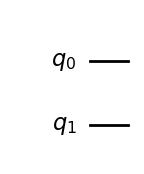

👉 Vector de estado:


<IPython.core.display.Latex object>

👉 Notación ket:


<IPython.core.display.Latex object>

👉 QSphere:


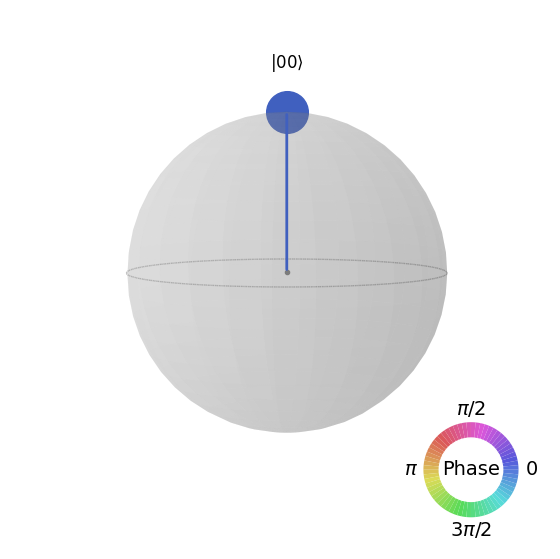

In [3]:
# PASO 1: crear un circuito con dos qubits.
# Los dos comienzan automáticamente en |0⟩.
circuito_base = QuantumCircuit(2)

# PASO 2: calcular el estado producido por el circuito vacío.
estado_base = Statevector.from_instruction(circuito_base)

# PASO 3: mostrar el circuito.
print("👉 Circuito inicial:")
display(circuito_base.draw('mpl'))

# PASO 4: mostrar el mismo estado como vector y como ket.
print("👉 Vector de estado:")
display(array_to_latex(estado_base.data))

print("👉 Notación ket:")
display(estado_base.draw('latex'))

# PASO 5: mostrar la QSphere del sistema completo.
print("👉 QSphere:")
display(plot_state_qsphere(estado_base))

### 🔎 Interpretación

- El vector tiene cuatro posiciones, una por cada estado base.
- Solo la amplitud de ∣00⟩ vale `1`.
- Las amplitudes de ∣01⟩, ∣10⟩ y ∣11⟩ valen `0`.
- La QSphere presenta un único punto porque el sistema está completamente en ∣00⟩.

---

# 🟦 SECCIÓN 02

# 🔄 Operaciones individuales

Aplicaremos X sobre diferentes qubits. Recuerda que el índice dentro de `.x(...)` indica qué línea debe modificarse.

## 2.1 Aplicar X al qubit 0

Como `q₀` ocupa la posición derecha de la etiqueta, la transformación es:

$$
|00\rangle\longrightarrow|01\rangle
$$

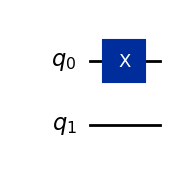

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

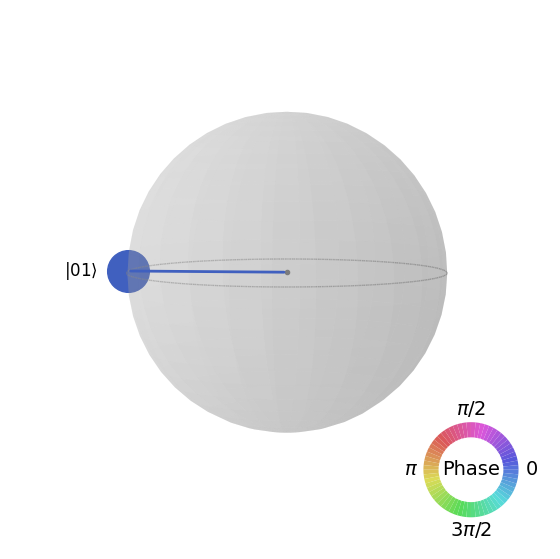

In [4]:
# Crear un circuito nuevo para este ejemplo.
circuito_x_q0 = QuantumCircuit(2)

# Aplicar X al qubit 0, que es el primer qubit.
circuito_x_q0.x(0)

# Calcular el estado final.
estado_x_q0 = Statevector.from_instruction(circuito_x_q0)

# Mostrar cada representación por separado.
display(circuito_x_q0.draw('mpl'))
display(array_to_latex(estado_x_q0.data))
display(estado_x_q0.draw('latex'))
display(plot_state_qsphere(estado_x_q0))

## 2.2 Aplicar X al qubit 1

Ahora cambia el segundo qubit, que ocupa la posición izquierda de la etiqueta:

$$
|00\rangle\longrightarrow|10\rangle
$$

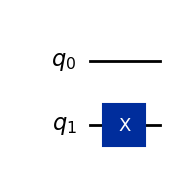

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

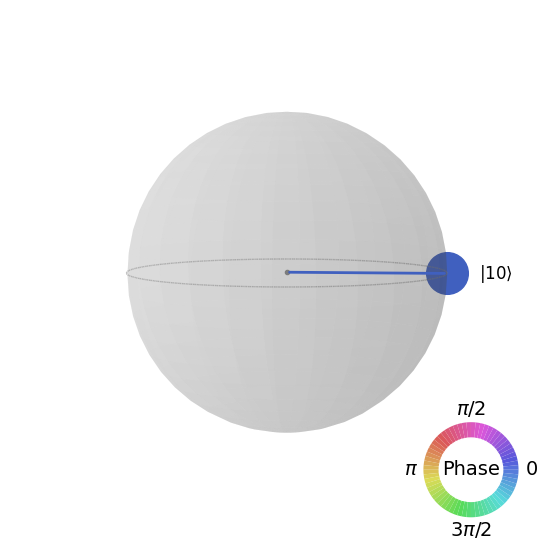

In [5]:
# Crear otro circuito independiente.
circuito_x_q1 = QuantumCircuit(2)

# Aplicar X al qubit 1, que es el segundo qubit.
circuito_x_q1.x(1)

# Calcular y mostrar el estado final.
estado_x_q1 = Statevector.from_instruction(circuito_x_q1)

display(circuito_x_q1.draw('mpl'))
display(array_to_latex(estado_x_q1.data))
display(estado_x_q1.draw('latex'))
display(plot_state_qsphere(estado_x_q1))

## 2.3 Aplicar X a ambos qubits

Cada X modifica una posición distinta:

$$
|00\rangle\longrightarrow|11\rangle
$$

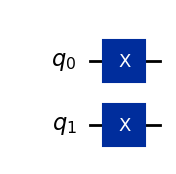

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

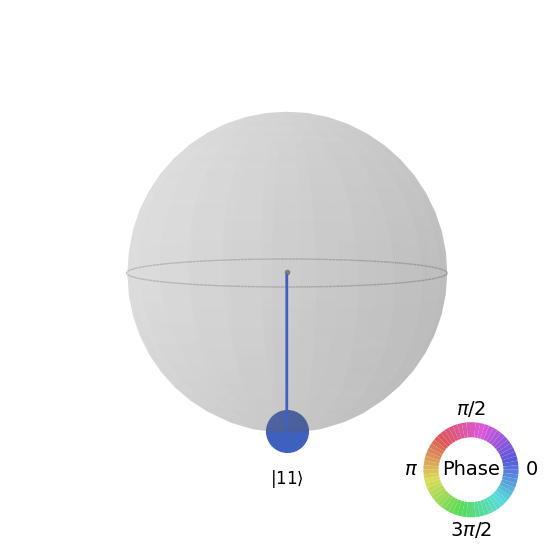

In [6]:
# Crear un circuito de dos qubits.
circuito_dos_x = QuantumCircuit(2)

# Aplicar X primero a q0 y después a q1.
circuito_dos_x.x(0)
circuito_dos_x.x(1)

# Calcular y visualizar el resultado.
estado_dos_x = Statevector.from_instruction(circuito_dos_x)

display(circuito_dos_x.draw('mpl'))
display(array_to_latex(estado_dos_x.data))
display(estado_dos_x.draw('latex'))
display(plot_state_qsphere(estado_dos_x))

### ✅ Comparación

| Compuertas aplicadas | Amplitud distinta de cero | Estado |
|---|:--:|:--:|
| Ninguna | Primera posición | ∣00⟩ |
| X en `q₀` | Segunda posición | ∣01⟩ |
| X en `q₁` | Tercera posición | ∣10⟩ |
| X en ambos | Cuarta posición | ∣11⟩ |

---

# 🟩 SECCIÓN 03

# ✳️ Superposición en dos qubits

H puede colocar un qubit en superposición sin modificar directamente al otro.

## 3.1 H sobre el qubit 0

$$
|00\rangle\longrightarrow\frac{|00\rangle+|01\rangle}{\sqrt{2}}
$$

El sistema tiene 50 % de probabilidad de producir `00` y 50 % de producir `01` al medirse en la base computacional.

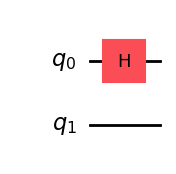

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

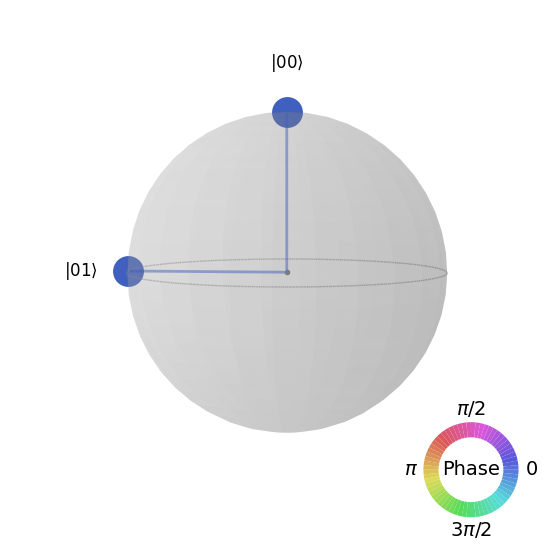

In [7]:
# Crear el circuito y aplicar H únicamente a q0.
circuito_h_q0 = QuantumCircuit(2)
circuito_h_q0.h(0)

# Calcular el estado en superposición.
estado_h_q0 = Statevector.from_instruction(circuito_h_q0)

# Mostrar circuito, vector, ket y QSphere.
display(circuito_h_q0.draw('mpl'))
display(array_to_latex(estado_h_q0.data))
display(estado_h_q0.draw('latex'))
display(plot_state_qsphere(estado_h_q0))

## 3.2 H sobre ambos qubits

Si aplicamos H a `q₀` y `q₁`, aparecen los cuatro estados base con la misma amplitud:

$$
|00\rangle\longrightarrow
\frac{|00\rangle+|01\rangle+|10\rangle+|11\rangle}{2}
$$

Cada resultado posee una probabilidad de 25 %.

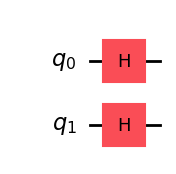

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

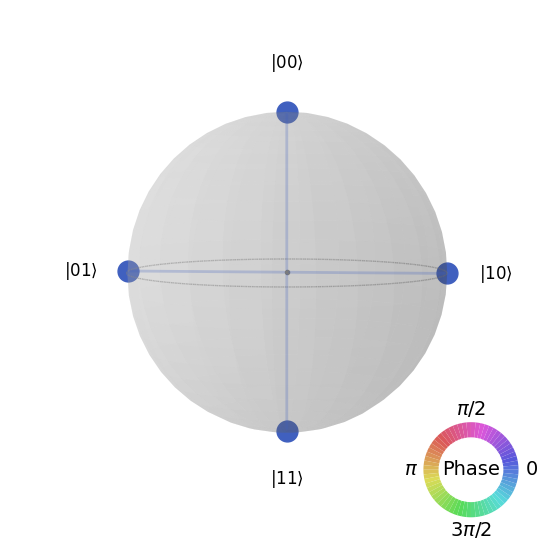

In [8]:
# Crear un circuito de dos qubits.
circuito_h_ambos = QuantumCircuit(2)

# Aplicar H a cada qubit por separado.
circuito_h_ambos.h(0)
circuito_h_ambos.h(1)

# Calcular y visualizar la superposición uniforme.
estado_h_ambos = Statevector.from_instruction(circuito_h_ambos)

display(circuito_h_ambos.draw('mpl'))
display(array_to_latex(estado_h_ambos.data))
display(estado_h_ambos.draw('latex'))
display(plot_state_qsphere(estado_h_ambos))

> 💡 En la QSphere, el tamaño de cada punto representa probabilidad y su color representa fase. Cuatro puntos del mismo tamaño indican cuatro resultados igualmente probables.

---

# 🟧 SECCIÓN 04

# 🔗 Entrelazamiento y estado de Bell

CNOT o CX necesita dos índices:

```python
circuito.cx(control, objetivo)
```

| Control | Objetivo antes | Objetivo después |
|:--:|:--:|:--:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Para crear el estado de Bell Φ⁺:

1. H coloca `q₀` en superposición.
2. CNOT utiliza `q₀` como control y `q₁` como objetivo.
3. Los dos qubits quedan correlacionados.

$$
|\Phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt{2}}
$$

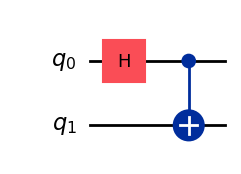

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

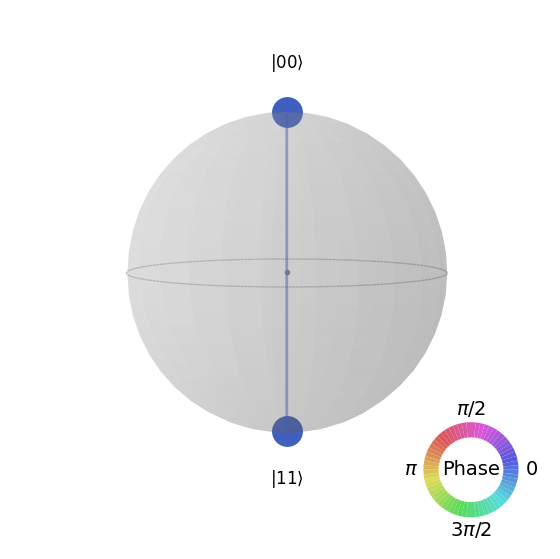

In [9]:
# Crear un circuito con dos qubits.
circuito_bell = QuantumCircuit(2)

# PASO 1: colocar q0 en superposición.
circuito_bell.h(0)

# PASO 2: entrelazar q0 y q1.
# El primer número es el control y el segundo es el objetivo.
circuito_bell.cx(0, 1)

# Calcular el estado conjunto.
estado_bell = Statevector.from_instruction(circuito_bell)

# Mostrar todas sus representaciones.
display(circuito_bell.draw('mpl'))
display(array_to_latex(estado_bell.data))
display(estado_bell.draw('latex'))
display(plot_state_qsphere(estado_bell))

### 🧠 ¿Qué significa el resultado?

| Resultado posible | Probabilidad |
|:--:|:--:|
| `00` | 50 % |
| `11` | 50 % |
| `01` | 0 % |
| `10` | 0 % |

No podemos describir el circuito como dos qubits independientes: la información está en la relación entre ellos. Si uno se mide como `0`, el otro también; si uno se mide como `1`, el otro también.

---

# 🟥 SECCIÓN 05

# 🔀 El orden de las compuertas

Qiskit agrega las operaciones en el orden en que aparecen en el código. Por ejemplo:

| Secuencia temporal | Código | Operador total |
|---|---|---|
| H → X | `.h(0)` y después `.x(0)` | XH |
| X → H | `.x(0)` y después `.h(0)` | HX |

Desde ∣00⟩, ambos circuitos producen 50 % para `00` y 50 % para `01`, pero sus fases son diferentes:

$$
XH|00\rangle=\frac{|00\rangle+|01\rangle}{\sqrt{2}}
$$

$$
HX|00\rangle=\frac{|00\rangle-|01\rangle}{\sqrt{2}}
$$

👉 H → X


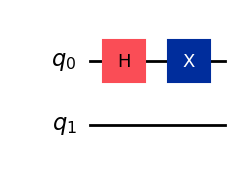

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

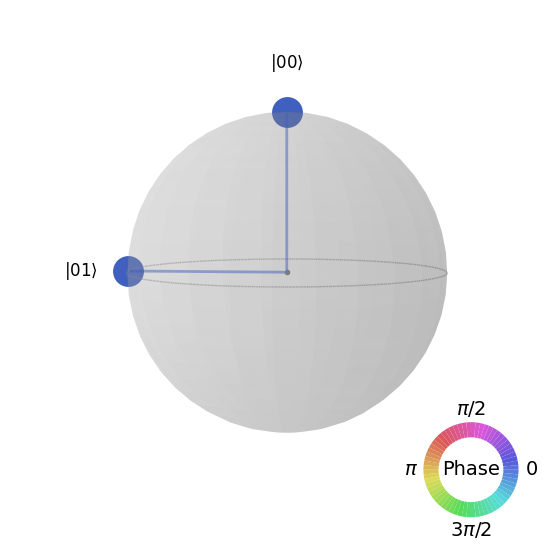

👉 X → H


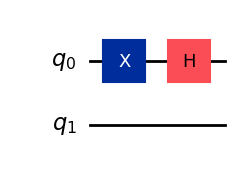

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

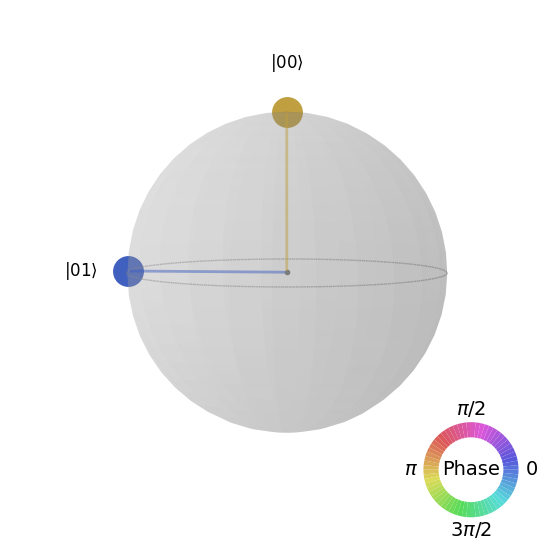

In [10]:
# CIRCUITO A: primero H y después X sobre q0.
circuito_hx = QuantumCircuit(2)
circuito_hx.h(0)
circuito_hx.x(0)
estado_hx = Statevector.from_instruction(circuito_hx)

# CIRCUITO B: primero X y después H sobre q0.
circuito_xh = QuantumCircuit(2)
circuito_xh.x(0)
circuito_xh.h(0)
estado_xh = Statevector.from_instruction(circuito_xh)

# Mostrar el primer orden.
print("👉 H → X")
display(circuito_hx.draw('mpl'))
display(array_to_latex(estado_hx.data))
display(estado_hx.draw('latex'))
display(plot_state_qsphere(estado_hx))

# Mostrar el orden contrario.
print("👉 X → H")
display(circuito_xh.draw('mpl'))
display(array_to_latex(estado_xh.data))
display(estado_xh.draw('latex'))
display(plot_state_qsphere(estado_xh))

> 🧠 **Conclusión:** observar solamente probabilidades no siempre permite distinguir estados. La QSphere y el vector también muestran la fase relativa.

---

# 🟨 SECCIÓN 06

# 🔔 Los cuatro estados de Bell

| Estado | Expresión | Correlación |
|:--:|---|---|
| **Φ⁺** | (∣00⟩ + ∣11⟩)/√2 | Mismos valores, misma fase |
| **Φ⁻** | (∣00⟩ − ∣11⟩)/√2 | Mismos valores, fase opuesta |
| **Ψ⁺** | (∣01⟩ + ∣10⟩)/√2 | Valores distintos, misma fase |
| **Ψ⁻** | (∣01⟩ − ∣10⟩)/√2 | Valores distintos, fase opuesta |

Todos son estados máximamente entrelazados. Los signos `+` y `−` indican la fase relativa entre sus componentes.

## 6.1 Estado Φ⁺

Comenzamos con H y CNOT:

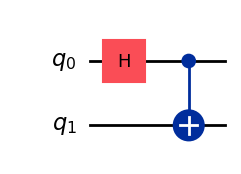

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

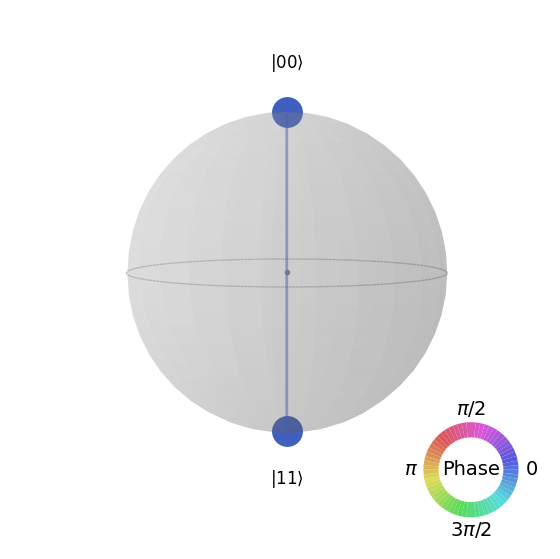

In [11]:
# Φ⁺ = (|00⟩ + |11⟩) / √2
phi_mas = QuantumCircuit(2)
phi_mas.h(0)
phi_mas.cx(0, 1)
estado_phi_mas = Statevector.from_instruction(phi_mas)

display(phi_mas.draw('mpl'))
display(array_to_latex(estado_phi_mas.data))
display(estado_phi_mas.draw('latex'))
display(plot_state_qsphere(estado_phi_mas))

## 6.2 Estado Φ⁻

Z cambia la fase del componente ∣11⟩:

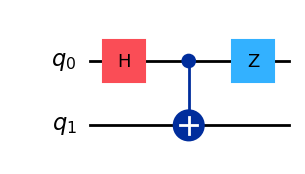

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

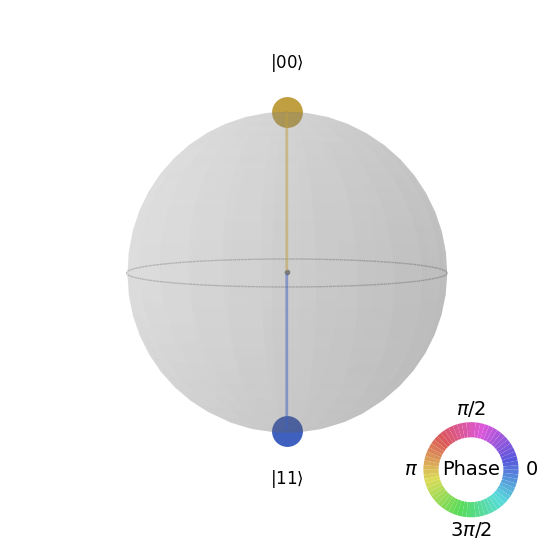

In [12]:
# Φ⁻ = (|00⟩ - |11⟩) / √2
phi_menos = QuantumCircuit(2)
phi_menos.h(0)
phi_menos.cx(0, 1)
phi_menos.z(0)  # Cambiar la fase cuando q0 vale 1.
estado_phi_menos = Statevector.from_instruction(phi_menos)

display(phi_menos.draw('mpl'))
display(array_to_latex(estado_phi_menos.data))
display(estado_phi_menos.draw('latex'))
display(plot_state_qsphere(estado_phi_menos))

## 6.3 Estado Ψ⁺

Después de crear Φ⁺, X sobre `q₀` cambia ∣00⟩ por ∣01⟩ y ∣11⟩ por ∣10⟩:

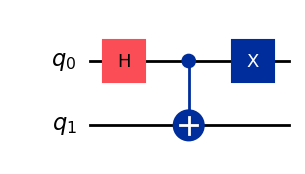

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

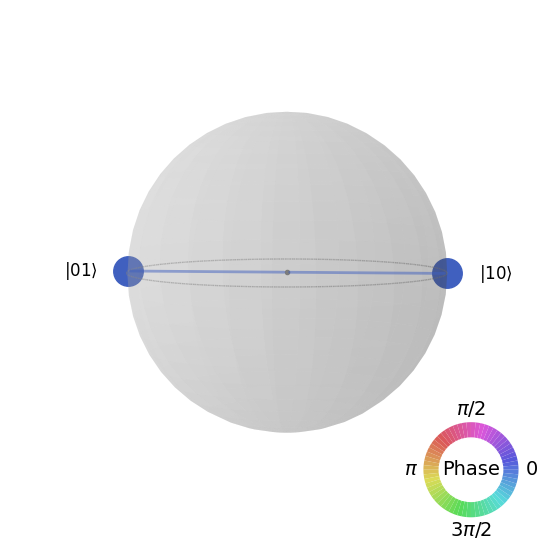

In [13]:
# Ψ⁺ = (|01⟩ + |10⟩) / √2
psi_mas = QuantumCircuit(2)
psi_mas.h(0)
psi_mas.cx(0, 1)
psi_mas.x(0)
estado_psi_mas = Statevector.from_instruction(psi_mas)

display(psi_mas.draw('mpl'))
display(array_to_latex(estado_psi_mas.data))
display(estado_psi_mas.draw('latex'))
display(plot_state_qsphere(estado_psi_mas))

## 6.4 Estado Ψ⁻

Finalmente, Z sobre `q₁` agrega la fase negativa al componente ∣10⟩:

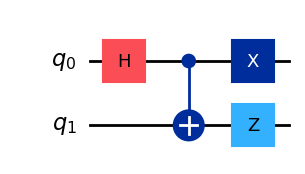

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

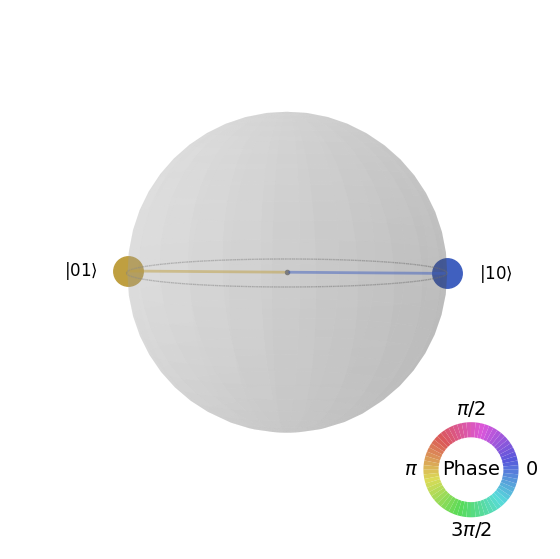

In [14]:
# Ψ⁻ = (|01⟩ - |10⟩) / √2
psi_menos = QuantumCircuit(2)
psi_menos.h(0)
psi_menos.cx(0, 1)
psi_menos.x(0)
psi_menos.z(1)
estado_psi_menos = Statevector.from_instruction(psi_menos)

display(psi_menos.draw('mpl'))
display(array_to_latex(estado_psi_menos.data))
display(estado_psi_menos.draw('latex'))
display(plot_state_qsphere(estado_psi_menos))

### 📊 Comparación visual

Ejecuta la siguiente celda después de construir los cuatro estados. Cada QSphere muestra los mismos tamaños de puntos, pero posiciones o colores diferentes.

🔔 Φ⁺


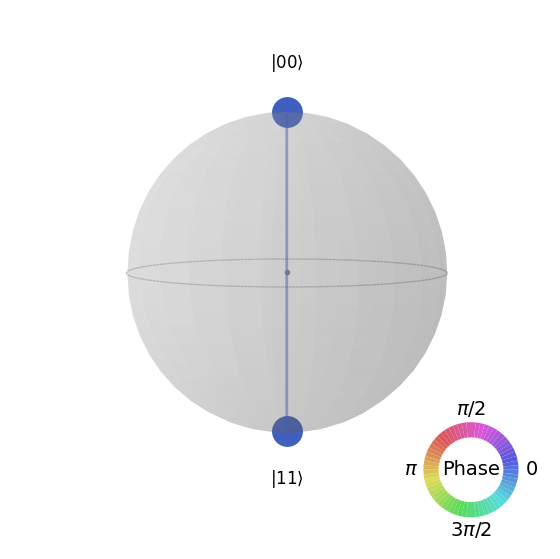

🔔 Φ⁻


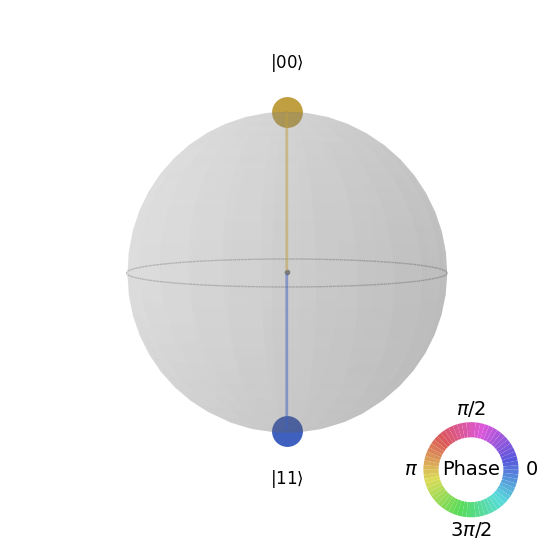

🔔 Ψ⁺


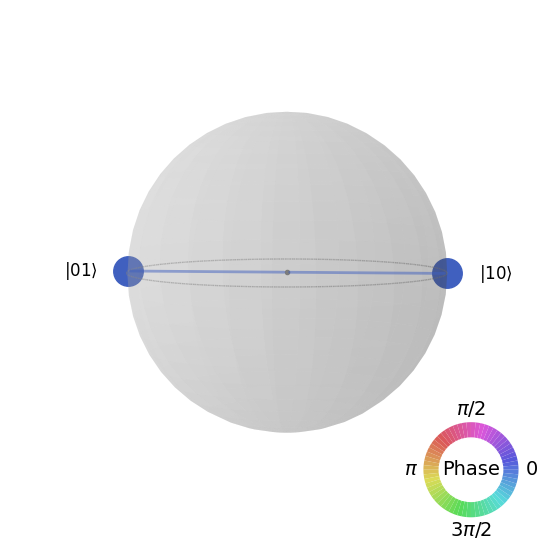

🔔 Ψ⁻


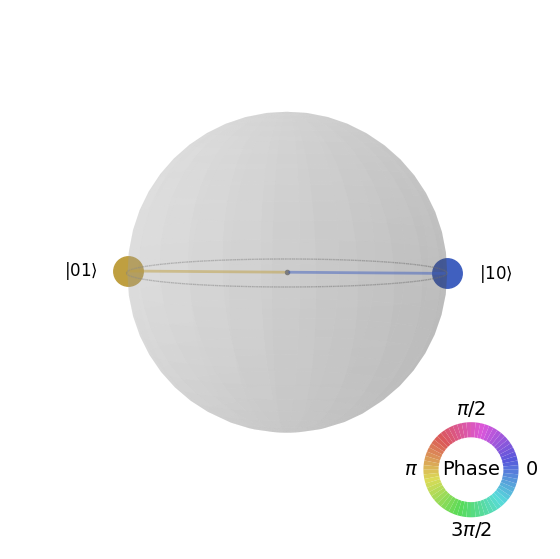

In [15]:
# Mostrar nuevamente las cuatro QSphere para compararlas una tras otra.
print("🔔 Φ⁺")
display(plot_state_qsphere(estado_phi_mas))

print("🔔 Φ⁻")
display(plot_state_qsphere(estado_phi_menos))

print("🔔 Ψ⁺")
display(plot_state_qsphere(estado_psi_mas))

print("🔔 Ψ⁻")
display(plot_state_qsphere(estado_psi_menos))

---

# 🟫 SECCIÓN 07

# 🧪 Ejercicios

Los ejercicios no incluyen respuestas. Completa las líneas marcadas con `TODO`, ejecuta las celdas y escribe tus conclusiones.

## Ejercicio 1 — Preparar ∣10⟩

Partiendo de ∣00⟩, aplica una sola compuerta para obtener ∣10⟩.

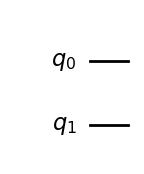

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

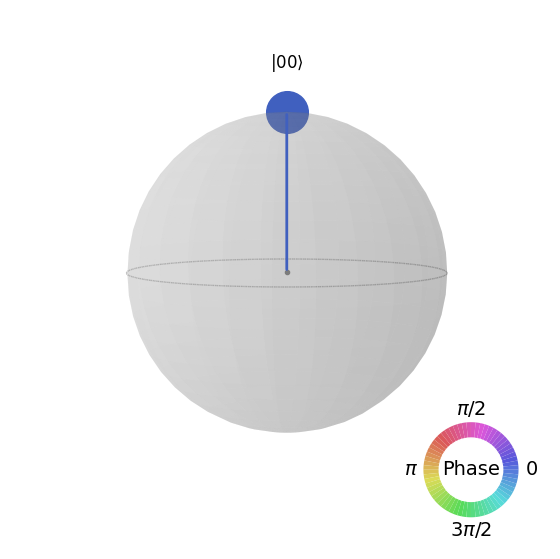

In [16]:
# Crear el circuito del ejercicio 1.
ejercicio_1 = QuantumCircuit(2)

# TODO: aplica X al qubit correcto.
# ejercicio_1.x(___)

# Calcular y mostrar tu resultado.
resultado_1 = Statevector.from_instruction(ejercicio_1)
display(ejercicio_1.draw('mpl'))
display(array_to_latex(resultado_1.data))
display(resultado_1.draw('latex'))
display(plot_state_qsphere(resultado_1))

### Tu conclusión

- Qubit modificado:  
- Posición distinta de cero en el vector:  
- Explicación del orden $q_1q_0$:  

---

## Ejercicio 2 — Superposición uniforme

Construye un circuito donde los cuatro estados base tengan probabilidad de 25 %.

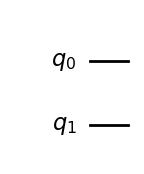

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

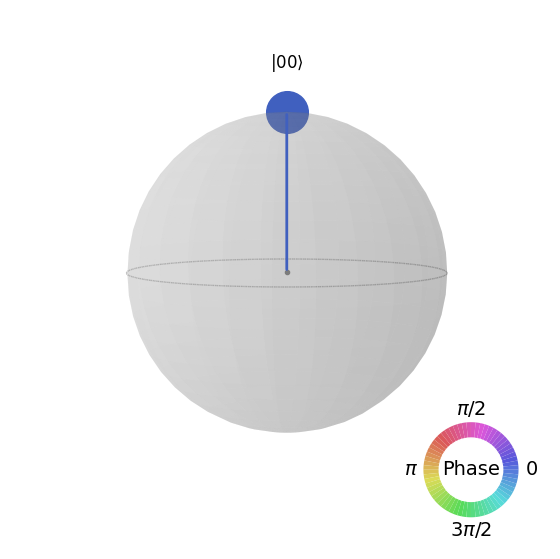

In [17]:
ejercicio_2 = QuantumCircuit(2)

# TODO: aplica H a cada uno de los dos qubits.
# ejercicio_2.h(___)
# ejercicio_2.h(___)

resultado_2 = Statevector.from_instruction(ejercicio_2)
display(ejercicio_2.draw('mpl'))
display(array_to_latex(resultado_2.data))
display(resultado_2.draw('latex'))
display(plot_state_qsphere(resultado_2))

### Tu conclusión

- Estados base visibles:  
- Amplitud de cada componente:  
- Probabilidad de cada resultado:  

---

## Ejercicio 3 — Construir Φ⁻

El circuito ya genera Φ⁺. Agrega una compuerta para cambiar su fase y obtener Φ⁻.

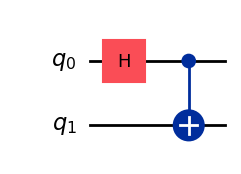

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

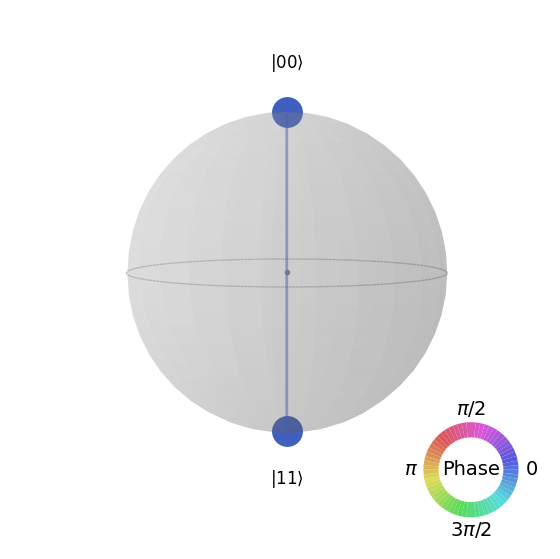

In [18]:
ejercicio_3 = QuantumCircuit(2)
ejercicio_3.h(0)
ejercicio_3.cx(0, 1)

# TODO: agrega una compuerta Z al qubit adecuado.
# ejercicio_3.z(___)

resultado_3 = Statevector.from_instruction(ejercicio_3)
display(ejercicio_3.draw('mpl'))
display(array_to_latex(resultado_3.data))
display(resultado_3.draw('latex'))
display(plot_state_qsphere(resultado_3))

### Tu conclusión

- Componentes del estado:  
- Diferencia de color respecto a Φ⁺:  
- ¿Cambió la probabilidad o la fase?:  

---

## Ejercicio 4 — Construir Ψ⁻

Parte del circuito Φ⁺ y agrega las operaciones necesarias para obtener Ψ⁻.

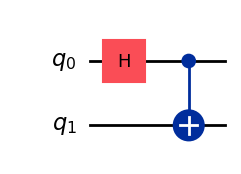

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

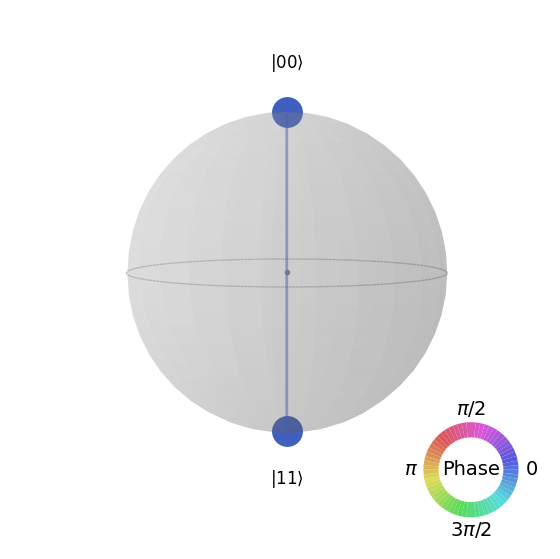

In [19]:
ejercicio_4 = QuantumCircuit(2)
ejercicio_4.h(0)
ejercicio_4.cx(0, 1)

# TODO: agrega X y Z en los qubits adecuados.
# ejercicio_4.x(___)
# ejercicio_4.z(___)

resultado_4 = Statevector.from_instruction(ejercicio_4)
display(ejercicio_4.draw('mpl'))
display(array_to_latex(resultado_4.data))
display(resultado_4.draw('latex'))
display(plot_state_qsphere(resultado_4))

### Tu conclusión

- Estados base presentes:  
- Signo relativo entre componentes:  
- Diferencia respecto a Ψ⁺:

---

# 🟧 CIERRE DEL MÓDULO

# 🎯 Ideas clave

- Dos qubits producen cuatro estados base.
- Qiskit muestra los kets en el orden $q_1q_0$.
- `q₀` aparece a la derecha del ket, aunque sea la primera línea del circuito.
- H puede crear superposición en uno o varios qubits.
- H seguida de CNOT puede crear entrelazamiento.
- El orden de las compuertas puede modificar la fase del estado.
- Los cuatro estados de Bell difieren en correlación y fase relativa.

## 📚 Referencias

1. [IBM Quantum — Construcción de circuitos](https://quantum.cloud.ibm.com/docs/en/guides/construct-circuits)
2. [IBM Quantum — Visualización de estados cuánticos](https://quantum.cloud.ibm.com/docs/en/guides/plot-quantum-states)
3. [Qiskit API — `Statevector`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector)
4. Nielsen, M. A. y Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press.
5. Hidary, J. (2021). *Quantum Computing: An Applied Approach*. Springer.

---

**Siguiente módulo:** medición, ejecuciones repetidas e histogramas.